# Crypto & Stock Market Exploratory Data Analysis (EDA)

This notebook analyzes the historical price data and technical indicators for the assets configured in the pipeline (`BTC-USD`, `ETH-USD`, etc. and Stocks).
The data used here is generated automatically by the DVC pipeline and resides in the `data/features` directory.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Plot styling
sns.set_theme(style="whitegrid", context="paper")
plt.rcParams['figure.figsize'] = (14, 7)


In [2]:
# Define data path relative to project root
data_path = Path("../data/features/multi_asset_features.csv")

if data_path.exists():
    df = pd.read_csv(data_path, parse_dates=['timestamp'])
    print(f"Dataset successfully loaded. Shape: {df.shape}")
    display(df.head())
else:
    print("Data file not found. Please ensure you have run the DVC pipeline ('uv run dvc repro').")


Dataset successfully loaded. Shape: (10872, 22)


,timestamp,close,return,log_return,ma_3,ma_7,ma_14,macd,macd_signal,macd_diff,...,bb_low,bb_width,bb_position,volatility_7,lag_1,lag_2,lag_3,target,asset_name,asset_type
0,2021-03-14,154.474503,0.000000,0.000000,154.474503,153.246432,152.425429,0.331572,0.254253,0.077319,...,147.207184,0.065671,0.716385,2.661400,154.474503,154.474503,155.679504,154.084000,AMZN,stock
1,2021-03-15,154.084000,-0.002528,-0.002531,154.344335,154.173074,152.195214,0.313620,0.283937,0.029684,...,147.752571,0.064029,0.641751,0.937975,154.474503,154.474503,154.474503,154.593002,AMZN,stock
2,2021-03-16,154.593002,0.003303,0.003298,154.383835,154.380288,152.185679,0.356106,0.320021,0.036085,...,148.439498,0.060844,0.654210,0.825882,154.084000,154.474503,154.474503,156.786499,AMZN,stock
3,2021-03-17,156.786499,0.014189,0.014089,155.154500,154.938073,152.652572,0.655384,0.487703,0.167681,...,149.159732,0.059433,0.818477,0.953905,154.593002,154.084000,154.474503,151.399506,AMZN,stock
4,2021-03-18,151.399506,-0.034359,-0.034963,154.259669,154.326645,152.832644,0.097085,0.292394,-0.195309,...,151.372673,0.037337,0.004747,1.571328,156.786499,154.593002,154.084000,153.748001,AMZN,stock


In [3]:
# Check available assets
if 'df' in locals():
    asset_counts = df['asset_name'].value_counts()
    print("Record count per asset:")
    print(asset_counts)
    
    print("\nMissing Values:")
    print(df.isnull().sum().max()) # Max missing values across columns


Record count per asset:
asset_name
ETH-USD    1813
BTC-USD    1813
SOL-USD    1813
AMZN       1811
IBM        1811
NVDA       1811
Name: count, dtype: int64

Missing Values:
0


## 1. Asset Price Trends
Let's visualize the historical closing prices over time for each asset.


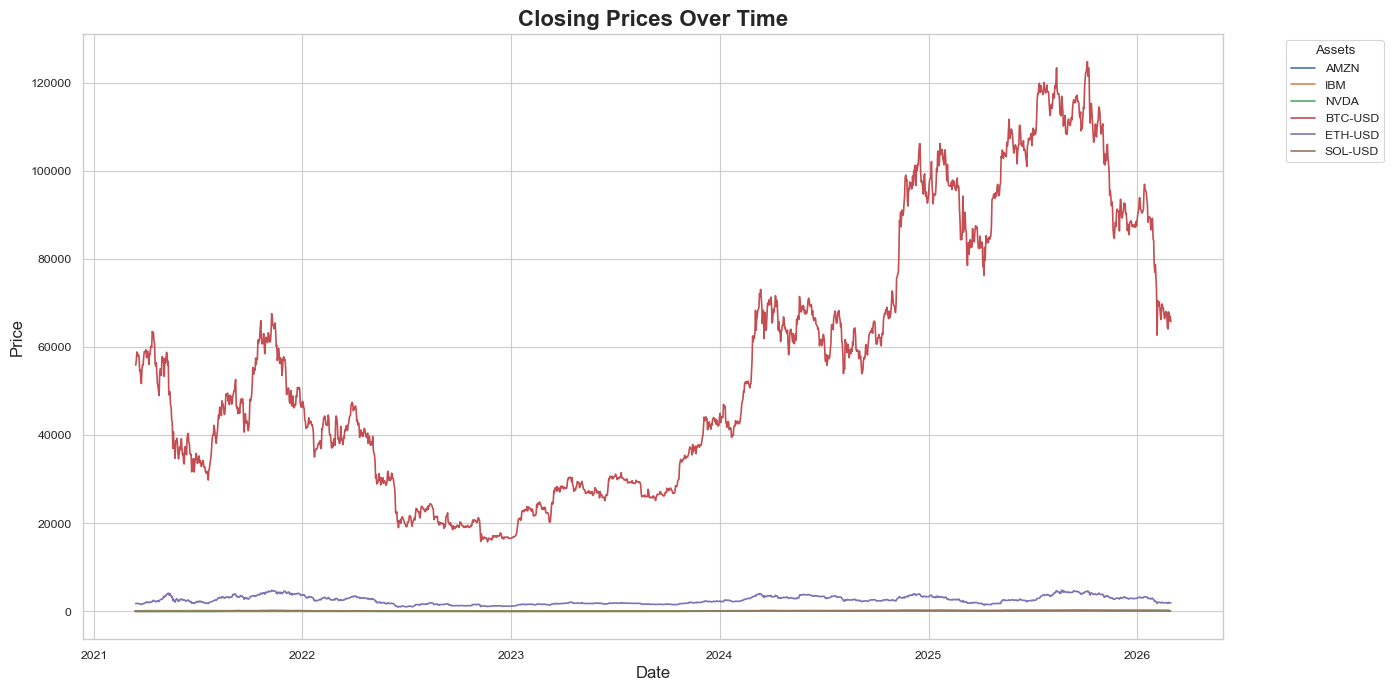

In [4]:
if 'df' in locals():
    plt.figure(figsize=(14, 7))
    for asset in df['asset_name'].unique():
        asset_data = df[df['asset_name'] == asset]
        plt.plot(asset_data['timestamp'], asset_data['close'], label=asset)
        
    plt.title('Closing Prices Over Time', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Price', fontsize=12)
    plt.legend(title="Assets", bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.show()


## 2. Daily Log Returns Distribution
Analyzing the volatility and return distribution of the assets.


/tmp/ipykernel_14265/3774057599.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(data=df, x='asset_name', y='log_return', palette='muted')


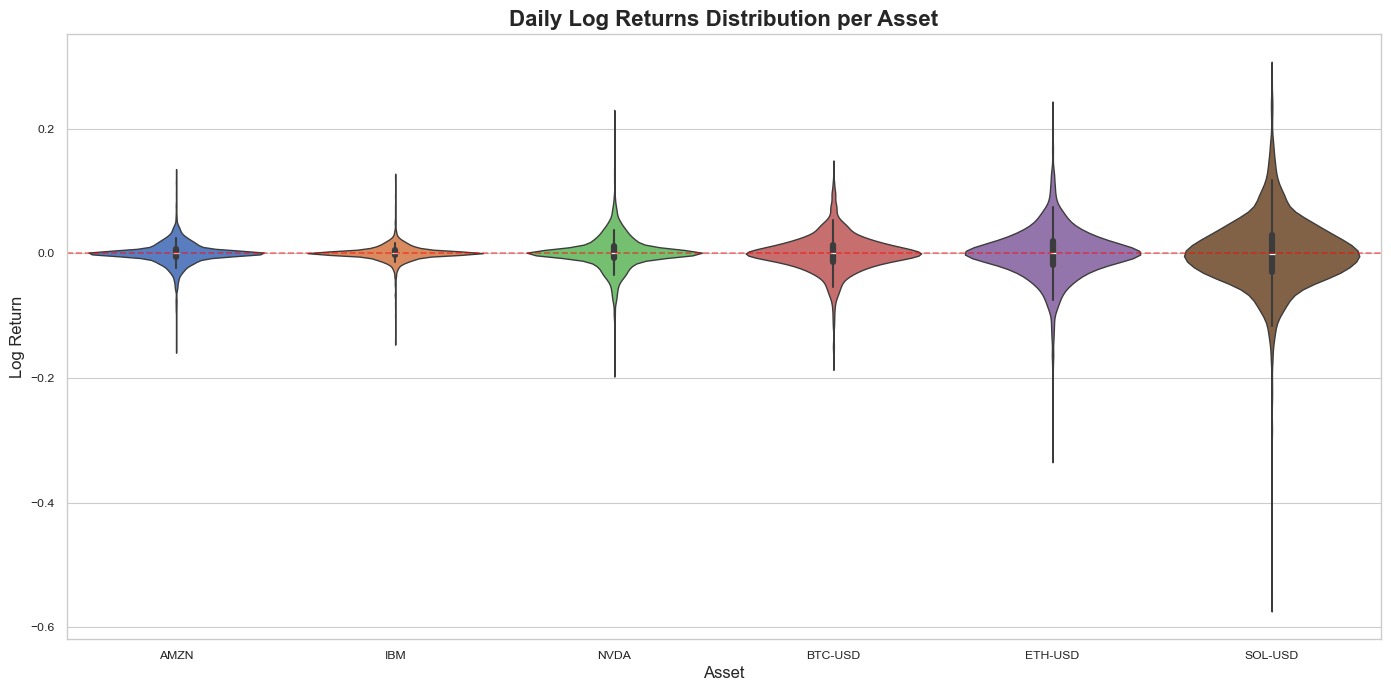

In [5]:
if 'df' in locals():
    plt.figure(figsize=(14, 7))
    sns.violinplot(data=df, x='asset_name', y='log_return', palette='muted')
    plt.title('Daily Log Returns Distribution per Asset', fontsize=16, fontweight='bold')
    plt.xlabel('Asset', fontsize=12)
    plt.ylabel('Log Return', fontsize=12)
    plt.axhline(0, color='red', linestyle='--', alpha=0.5)
    plt.tight_layout()
    plt.show()


## 3. Technical Indicators (Example: Bitcoin MACD)
A deep dive into a specific asset's technical indicators to see the pipeline's feature engineering in action.


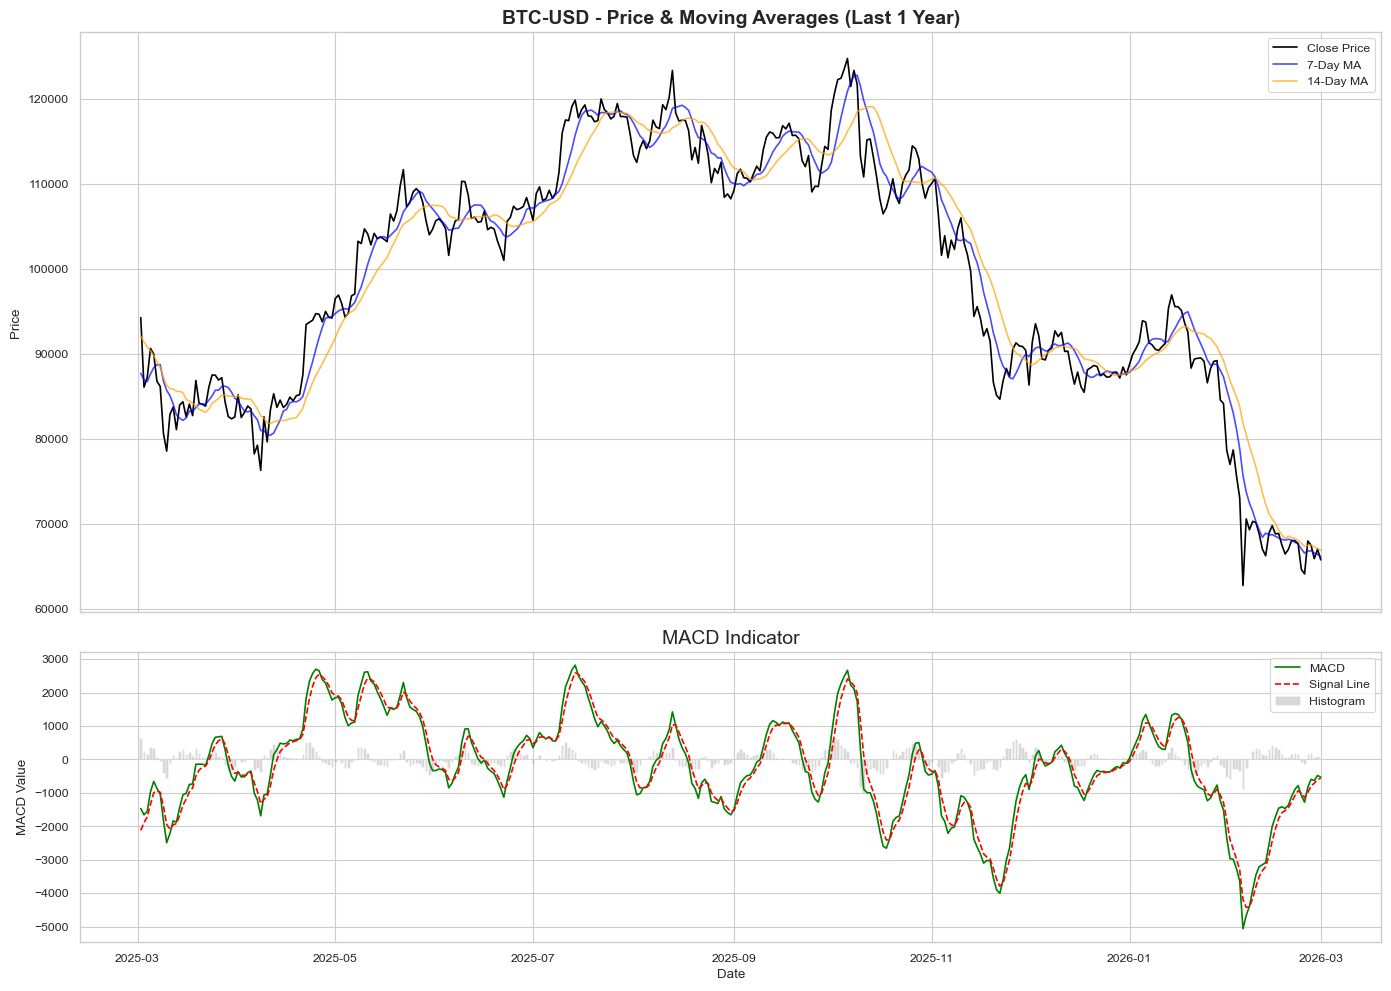

In [6]:
if 'df' in locals():
    # Filter for BTC or the first available asset
    target_asset = 'BTC-USD' if 'BTC-USD' in df['asset_name'].values else df['asset_name'].iloc[0]
    asset_data = df[df['asset_name'] == target_asset].tail(365) # Last 1 year
    
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(14, 10), sharex=True, gridspec_kw={'height_ratios': [2, 1]})
    
    # Plot Price and Moving Averages
    ax1.plot(asset_data['timestamp'], asset_data['close'], label='Close Price', color='black')
    ax1.plot(asset_data['timestamp'], asset_data['ma_7'], label='7-Day MA', color='blue', alpha=0.7)
    ax1.plot(asset_data['timestamp'], asset_data['ma_14'], label='14-Day MA', color='orange', alpha=0.7)
    ax1.set_title(f'{target_asset} - Price & Moving Averages (Last 1 Year)', fontsize=14, fontweight='bold')
    ax1.set_ylabel('Price')
    ax1.legend()
    
    # Plot MACD
    ax2.plot(asset_data['timestamp'], asset_data['macd'], label='MACD', color='green')
    ax2.plot(asset_data['timestamp'], asset_data['macd_signal'], label='Signal Line', color='red', linestyle='--')
    ax2.bar(asset_data['timestamp'], asset_data['macd_diff'], label='Histogram', color='gray', alpha=0.3)
    ax2.set_title('MACD Indicator', fontsize=14)
    ax2.set_ylabel('MACD Value')
    ax2.set_xlabel('Date')
    ax2.legend()
    
    plt.tight_layout()
    plt.show()


## 4. Feature Correlation Map
Understanding the linear relationships between the engineered features and the target variable.


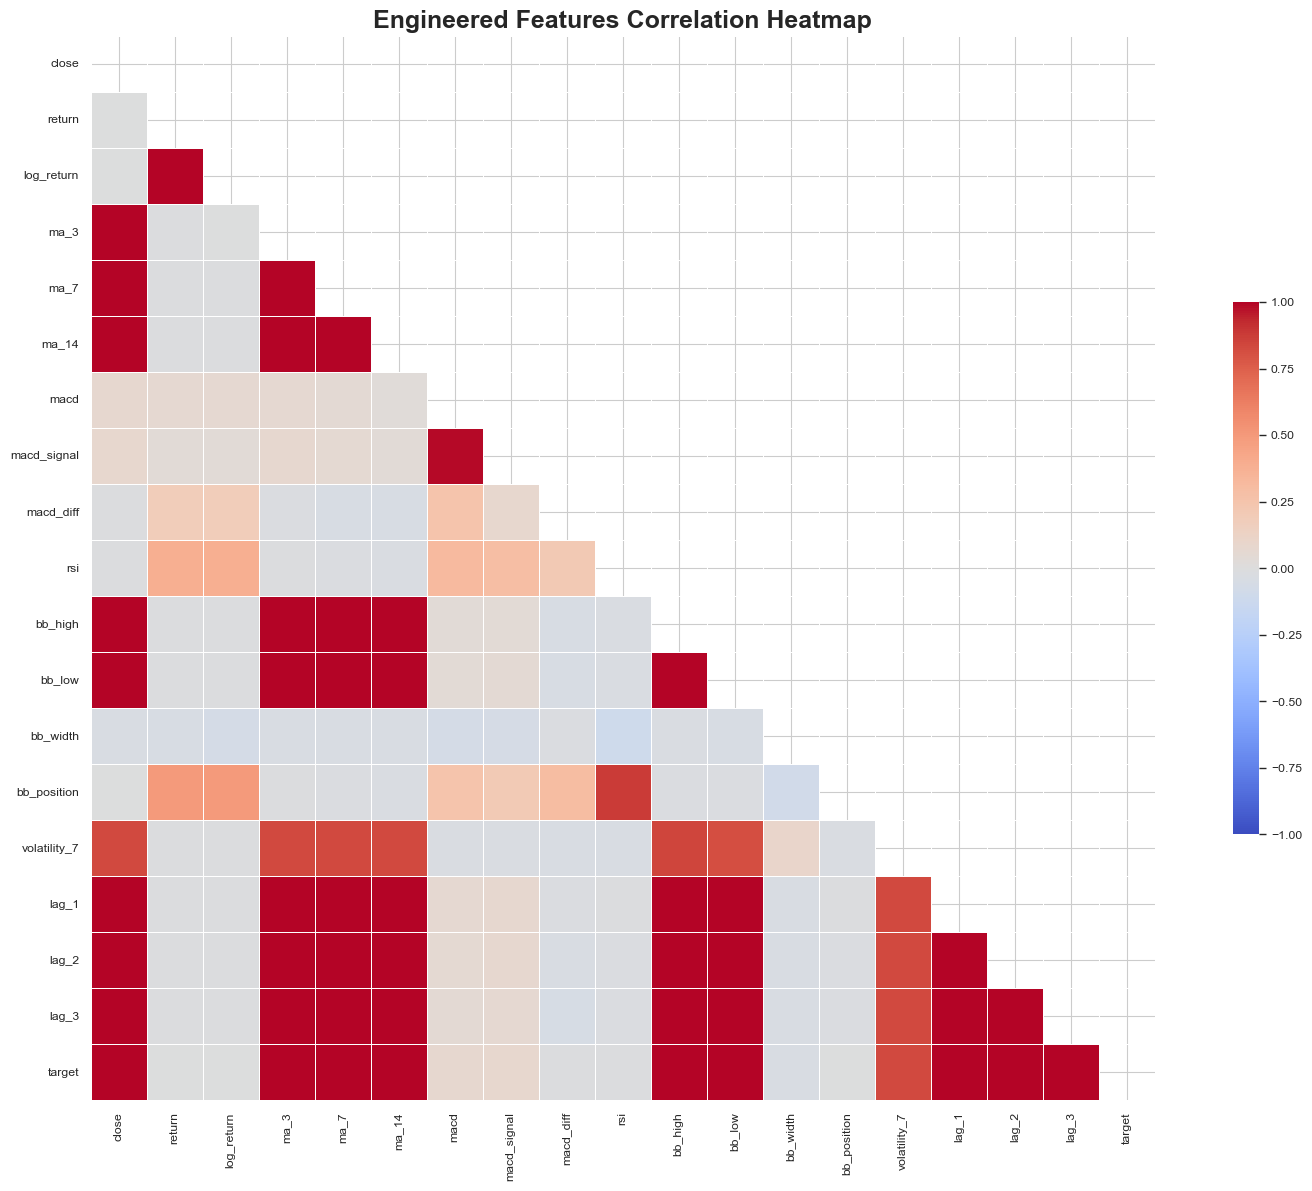

In [7]:
if 'df' in locals():
    plt.figure(figsize=(16, 12))
    
    # Exclude non-numeric columns
    numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
    corr_matrix = df[numeric_cols].corr()
    
    # Generate a mask for the upper triangle
    import numpy as np
    mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
    
    sns.heatmap(corr_matrix, mask=mask, annot=False, cmap='coolwarm', vmin=-1, vmax=1, center=0,
                square=True, linewidths=.5, cbar_kws={"shrink": .5})
    
    plt.title('Engineered Features Correlation Heatmap', fontsize=18, fontweight='bold')
    plt.tight_layout()
    plt.show()
